# Ejercicio k-Nearest Neighbor

## App Reviews
En este ejercicio vas a trabajar con una base de datos de reviews de una aplicación. Entre los datos podemos encontrar el texto de la review, las estrellas, así como el sentimiento del comentario (si es algo bueno o malo).

El objetivo es montar un algoritmo de clasificación que prediga el rating, en función del sentimiento del comentario y la cantidad de palabras empleadas en el mismo. Para ello tendrás que utilizar un algoritmo de tipo KNN.

## Importamos las librerías que vamos a utilizar

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Leemos nuestro archivo de entrada `reviews_sentiment`

Para facilitar el ejercicio, las columnas que utilizaremos serán: wordcount con la cantidad de palabras utilizadas y sentimentValue con un valor entre -4 y 4 que indica si el comentario fue valorado como positivo o negativo

Nuestras etiquetas, serán las estrellas que dieron los usuarios a la app, que son valores discretos del 1 al 5

In [31]:
import pandas as pd

reviews = pd.read_csv("data/reviews_sentiment.csv", sep=";")
reviews.head()

,Review Title,Review Text,wordcount,titleSentiment,textSentiment,Star Rating,sentimentValue
0,Sin conexión,Hola desde hace algo más de un mes me pone sin...,23,negative,negative,1,-0.486389
1,faltan cosas,Han mejorado la apariencia pero no,20,negative,negative,1,-0.586187
2,Es muy buena lo recomiendo,Andres e puto amoooo,4,NaN,negative,1,-0.602240
3,Version antigua,Me gustana mas la version anterior esta es mas...,17,NaN,negative,1,-0.616271
4,Esta bien,Sin ser la biblia.... Esta bien,6,negative,negative,1,-0.651784


In [32]:
features = reviews[["wordcount", "sentimentValue"]]
labels = reviews["Star Rating"]

In [33]:
print(reviews.isna().sum())
print(reviews.dtypes)


Review Title       0
Review Text        0
wordcount          0
titleSentiment    26
textSentiment      0
Star Rating        0
sentimentValue     0
dtype: int64
Review Title       object
Review Text        object
wordcount           int64
titleSentiment     object
textSentiment      object
Star Rating         int64
sentimentValue    float64
dtype: object


## Rápidas visualizaciones y análisis
Al menos realiza un análisis univariante y representa la distribución del rating. Realiza otras visualizaciones para ver la relación de tus datos.

C:\Users\Asier\AppData\Local\Temp\ipykernel_10472\539947600.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x="Star Rating", palette="viridis")


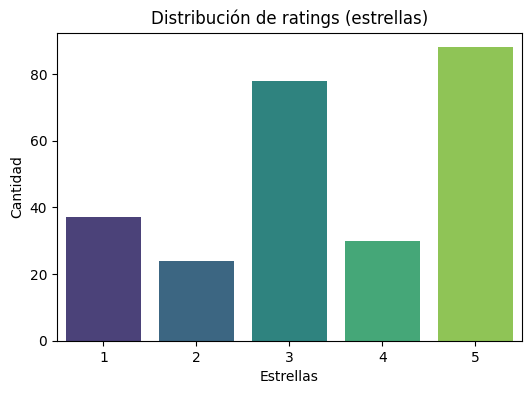

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(data=reviews, x="Star Rating", palette="viridis")
plt.title("Distribución de ratings (estrellas)")
plt.xlabel("Estrellas")
plt.ylabel("Cantidad")
plt.show()


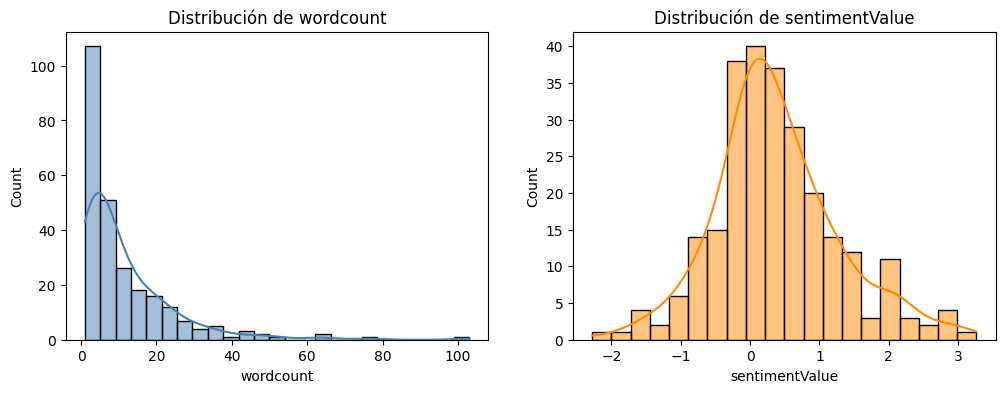

In [35]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(reviews["wordcount"], kde=True, ax=ax[0], color="steelblue")
ax[0].set_title("Distribución de wordcount")

sns.histplot(reviews["sentimentValue"], kde=True, ax=ax[1], color="darkorange")
ax[1].set_title("Distribución de sentimentValue")

plt.show()


## Preparamos el dataset
Divide en train/test y escala las features en el rango [0, 1].

In [36]:
X = reviews[["wordcount", "sentimentValue"]]
y = reviews["Star Rating"]

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [38]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
X_train_scaled

array([[0.02941176, 0.30220736],
       [0.06862745, 0.4812955 ],
       [0.20588235, 0.36344097],
       [0.32352941, 0.39549006],
       [0.06862745, 0.33153426],
       [0.04901961, 0.62296534],
       [0.07843137, 0.51037879],
       [0.12745098, 0.60112636],
       [0.06862745, 0.55808612],
       [0.20588235, 0.40707433],
       [0.        , 0.32524801],
       [0.28431373, 0.52558055],
       [0.01960784, 0.36136545],
       [0.04901961, 0.4446527 ],
       [0.10784314, 0.45246552],
       [0.07843137, 0.6331647 ],
       [0.14705882, 0.3906286 ],
       [0.47058824, 0.38182608],
       [0.10784314, 0.39284519],
       [0.09803922, 0.40146957],
       [0.20588235, 0.41409699],
       [0.47058824, 0.39792316],
       [0.        , 0.3189374 ],
       [0.03921569, 0.41272883],
       [0.11764706, 0.28385005],
       [0.03921569, 0.76889518],
       [0.01960784, 0.41198953],
       [0.        , 0.4343449 ],
       [0.00980392, 0.76250272],
       [0.00980392, 0.62638772],
       [0.

## Creamos el Modelo
Entrena con un KNN y evalúa el error en train y en test

In [40]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [41]:
train_acc = knn.score(X_train_scaled, y_train)
test_acc = knn.score(X_test_scaled, y_test)

print("Train accuracy:", train_acc)
print("Test accuracy:", test_acc)

Train accuracy: 0.9170731707317074
Test accuracy: 0.8269230769230769


In [42]:
train_error = 1 - train_acc
test_error = 1 - test_acc

print("Train error:", train_error)
print("Test error:", test_error)

Train error: 0.08292682926829265
Test error: 0.17307692307692313


## Evalúa tu modelo

In [43]:
from sklearn.metrics import accuracy_score

y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)

In [44]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           1       0.82      0.90      0.86        10
           2       0.40      1.00      0.57         2
           3       0.85      0.79      0.81        14
           4       1.00      0.43      0.60         7
           5       0.90      0.95      0.92        19

    accuracy                           0.83        52
   macro avg       0.79      0.81      0.75        52
weighted avg       0.86      0.83      0.82        52



## ¿Cómo obtener el mejor valor de k? Crea y evalúa nuevos modelos
¿Qué valor de k maximiza el accuracy? Representa todas las iteraciones en un scatterplot -> k vs accuracy

In [45]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    acc = knn.score(X_test_scaled, y_test)
    accuracies.append(acc)

In [46]:
best_k = k_values[accuracies.index(max(accuracies))]
best_acc = max(accuracies)

print("Mejor k:", best_k)
print("Accuracy máximo:", best_acc)

Mejor k: 2
Accuracy máximo: 0.8461538461538461


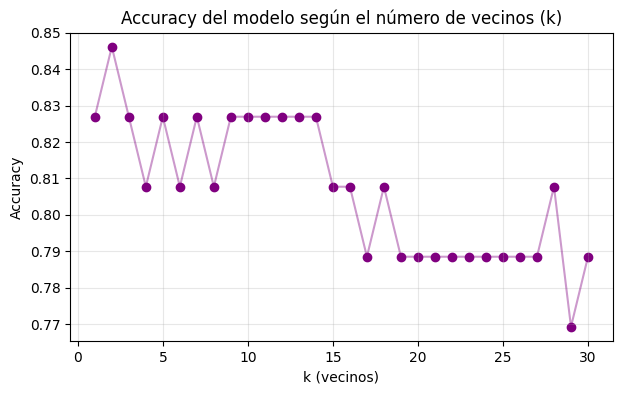

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.scatter(k_values, accuracies, color="purple")
plt.plot(k_values, accuracies, color="purple", alpha=0.4)
plt.xlabel("k (vecinos)")
plt.ylabel("Accuracy")
plt.title("Accuracy del modelo según el número de vecinos (k)")
plt.grid(True, alpha=0.3)
plt.show()


## Predice con nuevos datos.
Ejemplo: supongamos que nos llega una review de 5 palabras y sentimiento 1

In [48]:
import numpy as np

nuevo = np.array([[5, 1]])

In [49]:
nuevo_scaled = scaler.transform(nuevo)

c:\Users\Asier\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [50]:
prediccion = knn.predict(nuevo_scaled)
prediccion

array([5])

In [51]:
knn.predict_proba(nuevo_scaled)

array([[0.        , 0.        , 0.        , 0.03333333, 0.96666667]])